# <center>Milestone 1<center>
Name: Janani Dhileepan, CID: 06026467

## Introduction

### A. Research Proposal

**Overview:** I propose to write a paper on “Regulatory Vagueness and Fairness Drift: A Statistical Critique of Post-Deployment AI Monitoring" (working title).

The EU AI Act mandates post-deployment monitoring of high-risk AI systems for fairness but provides no statistical definitions at all. Not for fairness, not for drift, not for what constitutes a violation. In my dissertation, I will construct a fairness monitoring framework (a “smoke alarm”) using change point detection applied to fairness metrics over time. By doing so, I hope to demonstrate that the smoke alarm is sensitive to the choices embedded within it: which fairness metric is used, how each fairness metric is weighted, and which model is deployed. I hope to show that regulatory vagueness is not merely imprecise but actively exploitable; that is, a sophisticated actor can make pre-deployment choices that determine when, or whether, the alarm ever sounds.

**Motivation:** The EU AI Act became legally binding across the EU in 2024 but provides sparse statistical detail on how to classify, mitigate, and monitor high-risk AI systems (European Commission, 2026). Fairness is stated as a core principle, defined as AI that is "developed and used in a way that includes diverse actors and promotes equal access, gender equality and cultural diversity, while avoiding discriminatory impacts and unfair biases" (European Union, 2024, p.8). Articles 9 and 72 together require that providers maintain a risk management system and a post-market monitoring system to ensure continuous compliance. However, neither article provides any statistical definition of fairness, drift, or violation.

This vagueness has two consequences. First, no two monitoring systems will look alike in rigour or sensitivity. Second, given that all definitions of fairness cannot be simultaneously satisfied (Chouldechova, 2017), a strategic company may exploit this ambiguity to construct a monitoring system optimised for apparent compliance rather than genuine fairness. This paper illustrates that a post-deployment monitoring system is sensitive to the choice of fairness metric, metric weightings, and model, thereby exposing the mechanisms by which such exploitation can occur.

**Proposed Pipeline:**

Step 1 (Pre-Deployment Algorithms): The 2007 HMDA data are used as the pre-deployment period to train two classifiers — a logistic regression and a neural network — to predict loan approval.

Step 2 (Pre-Deployment Fairness Metrics): Using the trained classifiers, a composite fairness score is computed as a weighted combination of fairness measures. As Chouldechova (2017) establishes that no set of fairness measures can be simultaneously satisfied, the weights are an explicit and consequential modelling choice.

Step 3 (Post-Deployment Monitoring): For each year in the post-deployment period (2008-2017), the trained classifiers are applied and fairness metrics recomputed. A change point detection hypothesis test is used to detect whether and when fairness drifts — the "smoke alarm". This raises two design questions with no neutral answer: whether the baseline is fixed at 2007 or rolling (the former misses improvements, the latter misses creeping drift); and whether the alarm triggers on deterioration only or requires improvement (the latter institutionalises the baseline level of unfairness as acceptable).

Step 4 (Post-Hoc Analysis): A Monte Carlo simulation examines how pre-deployment weighting choices for the composite fairness score affect when, or whether, the alarm sounds post-deployment. Combined with a comparison across the two classifiers, this demonstrates that alarm behaviour is determined by choices made before deployment.

Step 5 (Time-Permitting): The experiment is replicated on a dataset from a different high-risk AI domain to test whether domain choice also shapes smoke alarm behaviour.

**Individual Contribution:** Below is the list of contributions that my work will add to the existing literature:

• The creation of a bespoke fairness measure. While each fairness metric within the fairness measure is well-established, the combination, along with their weightings, are an original formalisation for my research.

• The application of change point detection to fairness metrics over time. While both change point detection and measuring fairness are well-established fields, my paper will combine them for the first time to my knowledge.

• The Monte Carlo simulation linking pre-deployment weighting choices to post-deployment behaviour, making explicit one of the core arguments of my research: pre-deployment choices can be gamed to pre-emptively choose post-deployment alarm behaviour.

• The empirically backed regulatory critique of the EU AI Act’s vagueness, i.e., demonstrating statistically the mechanism of exploitability.

### B. Zip File Structure

The zip file attached includes: "cleaned_missing.csv", the dataset used to run all the code in this notebook; "clean_hmda_2007_2017.py", the code used to clean the raw dataset; "eda_hmda_2997_2017.ipynb", which takes "cleaned_missing.csv" and conducts exploratory data analysis; and "analysis_hmda_2007.ipynb", which runs preliminary analyses on the dataset. It also includes an 8-page PDF version of this notebook.

### C. Notebook Structure

The structure of this Notebook is as follows: In the next section, I discuss data structure, cleaning, and exploratory analysis. In the third section, I conduct preliminary analyses and build a fairness metric. In the fourth section, I summarise.

## Data

### A. Data Explanation

The data used are the US Home Mortgage Disclosure Act (HMDA) data, which requires financial institutions to publicly disclose loan-level information on mortgage applications, including demographics (race, sex, and ethnicity), income, loan amount, and approval outcome (Consumer Financial Protection Bureau, 2024). Notably, age is absent from the dataset.

A data collection change in 2007 made the data more publicly accessible and standardised, and a further change in 2018 introduced additional fields, creating a meaningful discontinuity. Merging the two periods is methodologically complex due to mismatched fields and higher rates of missing data post-2018, and adds little value given that the analysis requires only a pre-deployment period and a sufficiently long post-deployment window. I therefore use the 2007-2017 data only, defining 2007 as the pre-deployment period and 2008-2017 as the post-deployment period.

### B. Data Cleaning

The Python file in the zip ("clean_hmda_2007_2017.py") merges all eleven years of data, conducts preliminary cleaning, and treats missing variables. The variables retained are: year, action taken, race, sex, ethnicity, applicant income, loan amount, loan type, lien status, and tract-to-MSA/MD income. Tract-to-MSA/MD income is the ratio of neighbourhood income to the broader metropolitan area income, and serves as a proxy for neighbourhood wealth.

Missing data are handled in two ways. For non-sensitive fields, rows with missing data are dropped via listwise deletion, as the proportions are negligible. For sensitive fields (race, sex, ethnicity), standard imputation is ethically inappropriate — it is not valid, for example, to infer race from income — so missing values are retained as a distinct subgroup. Only observations with a definitive outcome are retained; records closed for incompleteness or withdrawn are dropped, as they provide no complete basis for classification.

### C. Exploratory Data Analysis

In this section, I discuss key findings during exploratory data analysis. Not all graphs and findings are included in this Notebook; for all graphs and findings, please refer to "eda_hmda_2007_2017.ipynb".

In [1]:
import os
os.getcwd()
os.chdir("../src")

In [2]:
%%capture
%run eda_hmda_2007_2017.ipynb

#### I. Continuous Variables EDA

The three continuous variables are: income, loan amount, and tract-to-MSA/MD income. All three variables are log-transformed as they are right-skewed distributions. This is to be expected as lower incomes are more common than higher incomes. As a result, the distributions are now roughly normally distributed.

Income and loan amount have clear outlier values (values above USD 5 million), and these are dropped. The cut-off was chosen conservatively: while it may be plausible to have values higher than this, they are unlikely, and dropping these entries are negligibly few, implying that dropping them will introduce negligible bias into the dataset. Tract-to-MSA/MD income has some values of 0 (implying that the income is 0, which is impossible as the lowest income is USD 1,000). These rows are dropped.

The histograms below show all three log-transformed variables with outliers removed. They are now roughly normally distributed, which is a core requirement for regressions.

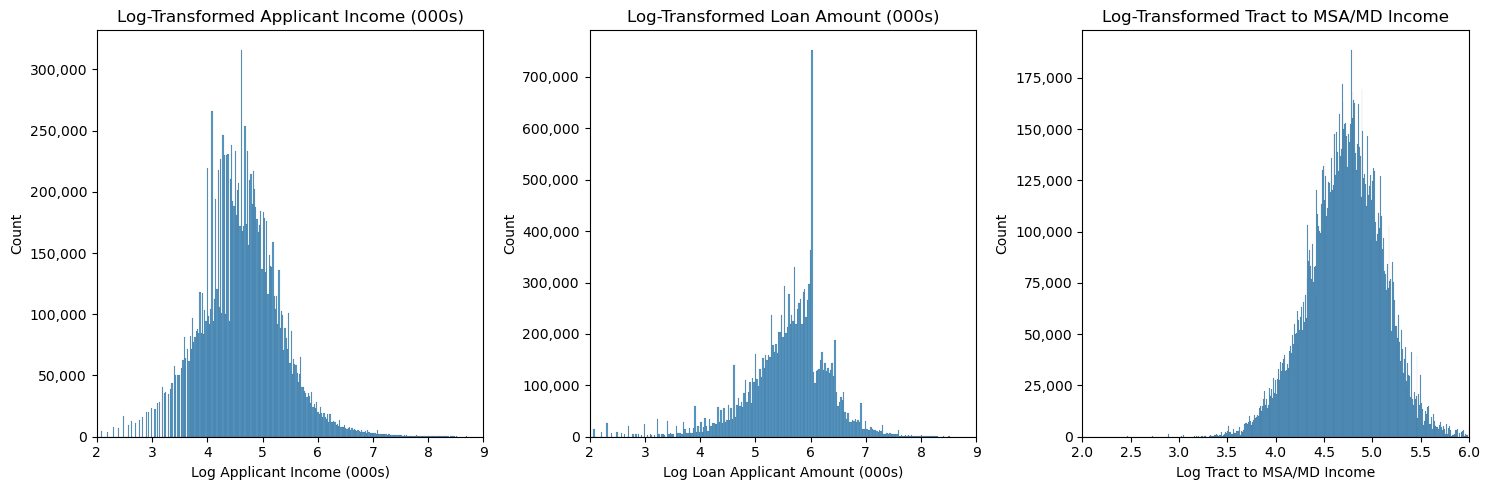

In [3]:
fig_cont

Note the spike in loan applicant amounts, which corresponds to around USD 417,000. This amount is the "conforming loan limit", i.e., the maximum size loan Fannie Mae and Freddie Mac would purchase, as it is easy to sell off. Loan requests just above that limit are shifted down to the conforming loan limit to get better interest rates. This is not an error of the data, but rather a facet of the loan market. To corroborate the existence of the conforming loan limit, the data frame below displays the spike amount at each year, along with the actual conforming loan limit as reported by the US Government (Federal Housing Finance Agency, 2024). Any marginal differences are due to binning decisions.

In [26]:
print(peak_df)

    Year  Peak log loan  Peak loan (USD)  Conforming loan limits (USD)
0   2007           6.03        415715.03                        417000
1   2008           6.03        415715.03                        417000
2   2009           6.03        415715.03                        417000
3   2010           6.03        415715.03                        417000
4   2011           6.03        415715.03                        417000
5   2012           6.03        415715.03                        417000
6   2013           6.03        415715.03                        417000
7   2014           6.03        415715.03                        417000
8   2015           6.03        415715.03                        417000
9   2016           6.03        415715.03                        417000
10  2017           6.05        424113.03                        424000


#### II. Categorical Variables EDA

**Action taken:** The outcome variable is bucketed so that action_taken == 1 indicates a loan was approved (regardless of whether the borrower ultimately accepted it), and action_taken == 0 indicates a loan was denied. The split between accepted and denied loans is 75/25. When running the logistic regression and neural network, this must be accounted for by weighting the two decisions appropriately (without weighting them, an algorithm that approves everyone will have a 75% accuracy).

**Sensitive characteristics:** The sensitive characteristics are race, sex, and ethnicity. By far, the largest race category is White, sex category is male, and ethnicity is non-Hispanic or Latino. As a result, in my logistic regression, these categories are used as the baseline groups.

#### III. Multivariate EDA

#### Sensitive group by approval rates across time

The figure below shows how the approval rates vary, for each sensitive characteristic, by their sub-groups. To note is that the difference between male and female applicants' approval rates reduces over time, without having a large gap to begin with. Race disparities, however, stay stubbornly wide. Compared to the highest approved group (Asians), American Indians/Alaska Natives and Black applicants have 15-20 percentage points difference in approval rates. These differences, while stark during the financial crisis (2007-2008), remain large even in 2017. A similar pattern is found for ethnicities.

When considering change point detection analysis, it is clear that for many races and ethnicities the disparity does not decrease with time, even if they may not increase. Choosing whether to have the alarm ring when disparity only gets worse, then, cements these disparities as normal. From a fairness perspective, such a conclusion should be avoided.

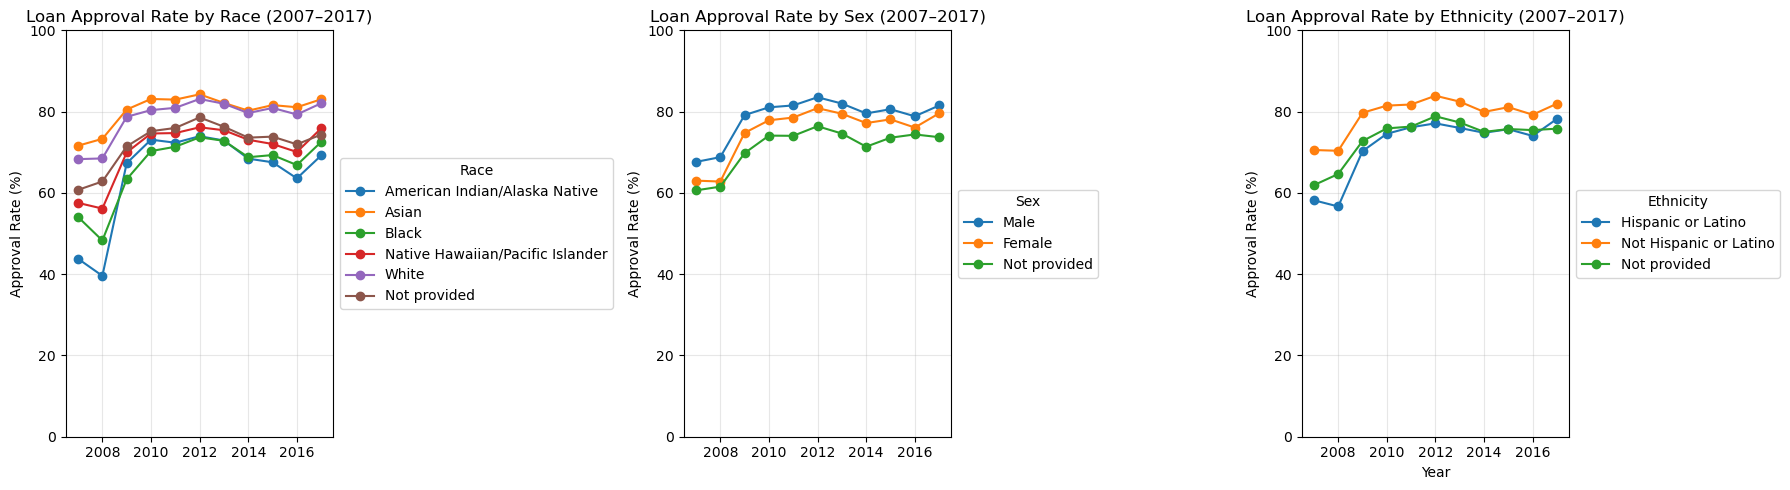

In [10]:
fig_sensitive_time

#### Sensitive group by loan amounts

The log-transformed loan amounts (shown below) across demographic groups reveals a structurally important pattern related to the conforming loan limit. For most racial groups, the loan amount distribution shows a bimodal shape; that is, a cluster below the conforming limit of USD 417,000 and a secondary cluster above it. This suggests a "bunching" effect whereby borrowers and lenders structure loans to stay below the conforming loan limit. However, this bimodal pattern is notably absent for Black and Hispanic applicants, whose loan amount distributions are concentrated below the conforming loan limit, consistent with their lower median incomes (identified in the "eda_hmda_2007_2017.ipynb" file). This suggests that the conforming loan limit, and the associated advantages it has, is structurally less accessible to these groups, representing a form of inequality that aggregate approval rate comparisons alone do not capture.

The smoother violins (e.g. American Indian/Alaskan Native) reflect a lack of data points.

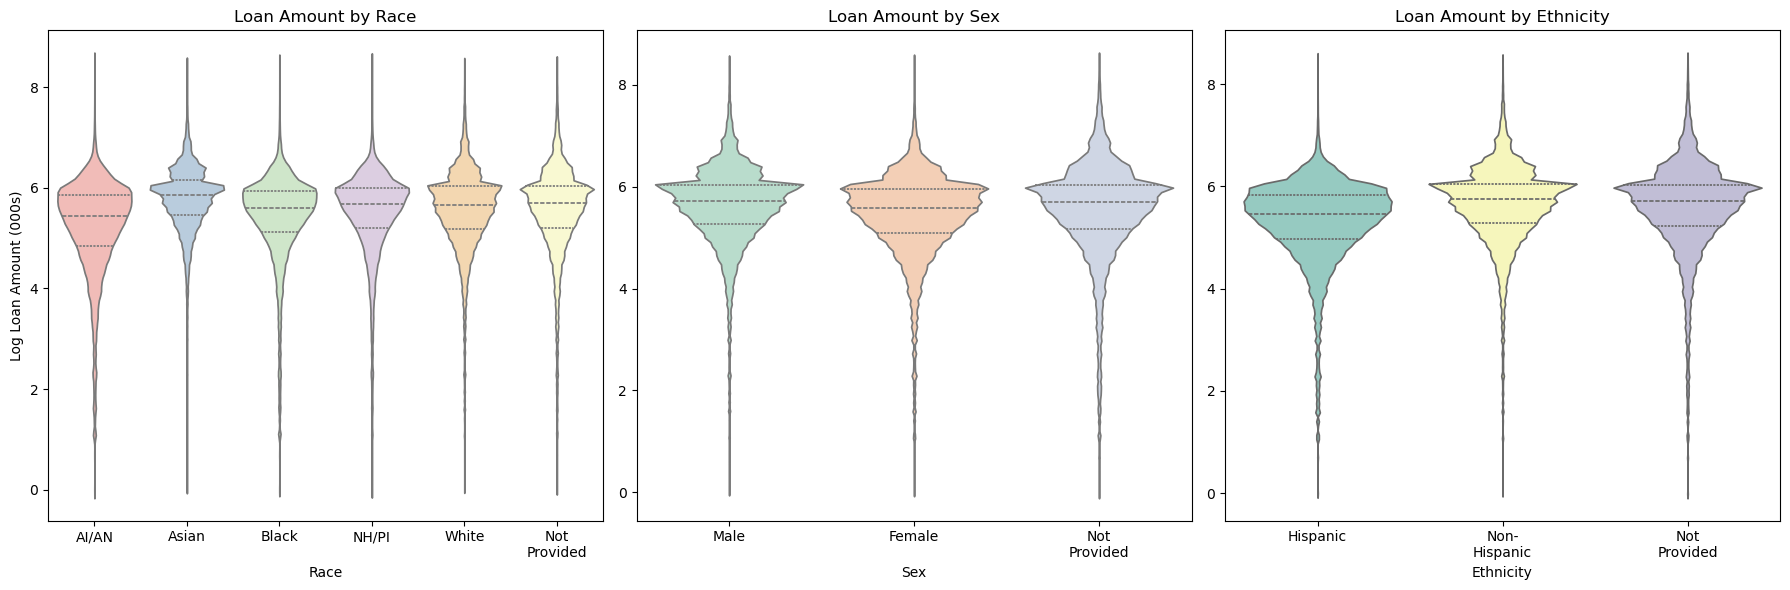

In [11]:
fig_violin

#### Sensitive group by loan type

The dataset contains two loan types with meaningful sample sizes: conventional loans dominate at approximately 13 million records, followed by FHA (Federal Housing Administration) loans at approximately 1.5 million. VA (Veterans Administration) and FSA/RHS (Farm Service Agency/Rural Housing Service) loans are negligible in size and excluded from approval rate analysis. Notably, Black and Hispanic applicants are disproportionately concentrated in FHA loans compared to White and Asian applicants, making loan type a potential mediating variable between race and approval outcome. This has implications for modelling: including loan type as a feature will capture only the direct effect of race on approval. Excluding it captures the total effect of race, including the portion that operates indirectly through loan type: the fact that minority applicants are disproportionately concentrated in categories with lower approval rates. This distinction matters for the fairness argument, as a regulator or company could choose whichever framing produces a more favourable fairness score, without changing the underlying reality.

#### Sensitive group by tract-to-MSA/MD income

When analysing sensitive groups by income and tract-to-MSA/MD income, the patterns show that ethnic and racial minority groups (apart from Asians) generally live in poorer neighbourhoods. Asians generally have higher levels of income than any other group, and generally live in richer neighbourhoods. The difference between male and female applicants, in comparison, is not as stark.

#### Continuous variables multicollinearity checks

There is little evidence of multicollinearity between continuous variables. A pair plot of the three variables shows no discernible pattern, and the Pearson Correlation Matrix further confirms this. The highest correlation is between income and loan amount, at 51% correlation.

### IV. Key dissertation-relevant observations:

1. The data independently validates a known regulatory change — the 2017 conforming loan limit increase.

2. Loan type explains part of the race-outcome relationship, a feature not easy to see by approval rate metrics alone.

3. The smoke alarm monitors drift rather than level — a persistently unfair but stable system would never trigger it. The challenge is noticeable in the graph of sensitive characteritics and approval across time.

4. The choice of which sensitive attribute to monitor matters — in an extreme example, a system monitoring only sex would miss the far more significant disparities by race and ethnicity, directly supporting my metric selection and weighting argument.

## Analysis

In this section, I explain my completed logistic regression and my fairness metric formula.

### A. Logistic Regression

In [20]:
os.getcwd()
os.chdir("../../src")

In [21]:
%%capture
%run analysis_hmda_2007.ipynb

#### I. Train/test split and balanced class weights

A logistic regression was trained on 2007 data using an 80/20 train-test split, with class_weight='balanced' to correct for the approximately 66/34 approval/denial imbalance. Without this correction, a naive model achieves 67% accuracy by approving nearly all applicants, but correctly identifies only 2% of denials. Balancing the class weights forces the model to learn to distinguish approvals from denials, yielding 57% accuracy but meaningful predictive signal in both directions.

The model uses only income, loan amount, neighbourhood income ratio, loan type, and lien status. Race, sex, and ethnicity are deliberately excluded, mirroring a realistic deployment scenario. As a diagnostic check, re-estimating the model with protected characteristics included raised accuracy by only 2 percentage points, confirming that any fairness disparities emerge from structural correlations rather than explicit encoding of protected characteristics.

Predictive accuracy is not the objective of this research. The goal is to establish a working baseline whose fairness properties can be monitored over time, not to build the most accurate mortgage approval model. This is consistent with the broader HMDA literature, where even well-specified models incorporating macroeconomic factors achieve accuracies in the low 80s — a modest ceiling given the naive approval rate is already 75%, and one explained by the many approval-determining factors unobserved in the data, such as credit scores and debt-to-income ratios.

The table below shows the logistic regression coefficients. All signs are in the expected direction. Notably, log_tract_to_msamd_income is the strongest continuous predictor, with direct fairness implications given the residential segregation patterns documented in the EDA. The VA loan coefficient of 0.96 is striking but explicable: in 2007, lenders were actively de-risking their portfolios, making the VA government guarantee particularly attractive. This is likely a crisis-specific effect. Lien status coefficients follow an intuitive pattern, with subordinate and unsecured liens penalised heavily relative to first liens. The intercept is not substantively interpretable.

In [23]:
print(results_1)
print("Intercept:", logreg.intercept_[0])

                    Variable  Coefficient
0            log_income_000s     0.446106
1       log_loan_amount_000s    -0.453105
2  log_tract_to_msamd_income     0.538375
3                loan_type_2     0.332332
4                loan_type_3     0.964035
5              lien_status_2    -0.915310
6              lien_status_3    -2.400050
Intercept: -1.9051454614052852


#### II. No train/test split and balanced class weights

A second logistic regression was run on the entire 2007 dataset, which will serve as the baseline by which future fairness metrics and change point analyses are conducted. The results are similar to the previous logistic regresison model with an 80/20 train/test split: all variable coefficients are similar and precision and recall are well-balanced.

### B. Fairness Metrics

In the below, I discuss my fairness metric, with which I will calculate the "unfairness" score for the baseline logistic regression from 2007. The three components of fairness (demographic parity, equalised odds, and calibration, are standard in fairness literature). The unfairness score is of my own construction, especially: (1) reweighting calibration to be on the same scale as demographic parity and equalised odds, (2) weight assignments to each fairness measure whose sum must be 1, and (3) the aggregation across protected attributes, as most papers use a binary protected attribute.

#### I. Composite Unfairness Score

$$\text{Unfairness} = \alpha \cdot DP + \beta \cdot EO + \gamma \cdot CAL$$

where $\alpha + \beta + \gamma = 1$ and all weights are non-negative. Higher scores indicate greater unfairness. The three metrics are in tension by construction: when base rates differ across groups, DP, EO, and CAL cannot all equal zero simultaneously (Chouldechova, 2017), so the weights encode a substantive choice about which form of unfairness is prioritised.

#### II. Demographic Parity (DP)

$$DP = \sum_{a=1}^A \sum_{g=2}^{G_a} \left| P(\hat{y}=1 \mid g,a) - P(\hat{y}=1 \mid 1,a) \right|$$

Measures whether approval rates differ across subgroups, where $g=1$ denotes the reference subgroup for attribute $a$.

#### III. Equalised Odds (EO)

$$EO = \sum_{a=1}^A \sum_{g=2}^{G_a} \left( \left| P(\hat{y}=1 \mid y=1,g,a) - P(\hat{y}=1 \mid y=1,1,a) \right| \right. \\ \quad + \left. \left| P(\hat{y}=1 \mid y=0,g,a) - P(\hat{y}=1 \mid y=0,1,a) \right| \right)$$

Measures whether TPR and FPR differ across subgroups.

#### IV. Calibration (CAL)

$$CAL = \frac{1}{B}\sum_{a=1}^A \sum_{g=2}^{G_a} \sum_{b=1}^B \left| P(\hat{y}=1 \mid b,g,a) - P(\hat{y}=1 \mid b,1,a) \right|$$

Measures whether predicted probabilities reflect actual outcomes equally across subgroups. Dividing by $B$ ensures comparability with DP and EO regardless of bin count; results should be checked for sensitivity to this choice.

**Reference groups:** Race: White; Ethnicity: Not Hispanic or Latino; Sex: Male. $a$ indexes protected attributes, $g$ indexes subgroups within each attribute.

## Summary

This notebook describes my research proposal, which is to empirically demonstrate that the EU AI Act's vagueness in defining post-deployment fairness will lead to exploitable smoke alarms. The notebook then describes the HMDA dataset, cleaning decisions, and exploratory data analysis. Finally, the notebook describes the logsitic regressions used for the 2007 dataset and my construction of an unfairness metric.

## References

Chouldechova, A. (2017) ‘Fair prediction with disparate impact: A study of bias in recidivism prediction instruments’, Big Data, 5(2), pp. 153–163. doi: 10.1089/big.2016.0047 (Accessed: 4 June 2026).

Consumer Financial Protection Bureau (2024) Home Mortgage Disclosure Act (HMDA) Data. Available at: Consumer Financial Protection Bureau HMDA Data (Accessed: 5 June 2026).

European Commission (2026) AI Act. Shaping Europe’s Digital Future. Available at: https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai (Accessed: 4 June 2026).

European Union (2024) Regulation (EU) 2024/1689 of the European Parliament and of the Council of 13 June 2024 laying down harmonised rules on artificial intelligence (Artificial Intelligence Act). Official Journal of the European Union, L 2024/1689. Available at: https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=OJ:L_202401689 (Accessed: 4 June 2026).

Federal Housing Finance Agency (2024) The Dynamics of FHFA Conforming Loan Limits and House Prices. 26 November. Available at: https://www.fhfa.gov/blog/insights/the-dynamics-of-fhfa-conforming-loan-limits-and-house-prices (Accessed: 5 June 2026).

National Credit Union Administration (2019) FFIEC Announces Availability of 2018 Data on Mortgage Lending. 30 August. Available at: https://ncua.gov/newsroom/press-release/2019/ffiec-announces-availability-2018-data-mortgage-lending (Accessed: 5 June 2026).